# Benchmark 

This script will benchmark a targeted gene panel against an annotated reference dataset. In the [first section](#Import-packages-and-targeted-panel), we will load the required packages and the targeted gene panel.

In the [second part](#Define-functions), we will define a few functions, that will do the benchmarking. This is the main part of the script.

Lastly, in a [third part](#Benchmark-against-a-uterus-reference-dataset), we will evaluate the targeted gene panel against an annotated uterus reference dataset.


## A little bit of theory

So how does the benchmarking work? We need an annotated scRNA dataset, where all cells are annotated. This annotation is the "ground truth" that we will compare against. This reference annotation can be a leiden clustering or a cell type annotation.

Next, we will subset the full single cell dataset to either the highly-variable genes (standard for scRNA analysis) or to the genes in the targeted gene panel. Using this reduced dataset, we will try to get a new annotation for each cell. We do this by connecting each cell to its 5 nearest neighbors (in PCA space) and then assign the new annotation based on the most abundant "ground truth" of the neighboring cells.

![A cell will be assigned a new label based on its nearest neighbors](images/NN.png)

The figure above illustrates how the new labels will be assigned. The colors (red and blue) represent the ground truth of the cells (in other words, the reference annotation) and the gray cell is the one, where we are trying to identify a new label. In panel (**a**) the gray cell is next to 4 red cells and 1 blue cell; hence the new predicted label would be *red*. In panel (**b**) the cell is close to 3 blue and 2 red cells, and hence, we would assign a blue label as the new annotation. 

Since we subsetted the entire dataset on (1) the highly variable genes and (2) the targeted gene panel, we will get different new (predicted) labels for both of them as the nearest neighbors will change. So how can we find out, if the new labels align with the "ground truth"? There are (at least) two metrics that we can use: AMI and ARI. Both compare the similarity between two clustering and are available through `scikit-learn`. (See here for more information about [AMI](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_mutual_info_score.html) and [ARI](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html)). Both metrics will give a score, and if the score is closer to 1, it means, that the similarity between the two annotations is better. 

In our case, we are comparing the reference annotation ("ground truth") against the predicted labels based on the nearest neighbors, and hence, how well the overall structure of the dataset is kept if we only consider the highly variable genes or the genes that are present in the targeted gene panel.

## Import packages and targeted panel

In this section, we import the required python packages and load the targeted gene panel.

In [1]:
from sklearn.metrics import adjusted_rand_score
import scanpy as sc
import statistics as stats
import pandas as pd
import os
import numpy as np
from sklearn.metrics.cluster import adjusted_mutual_info_score
import matplotlib.pyplot as plt
#import scvi
import warnings
warnings.filterwarnings('ignore')

In [2]:
base_dir = '/home/workspace/private/projects/kim'
panel_dir = os.path.join(base_dir, 'panel/csv/')
adata_path = os.path.join(base_dir, 'data/scrna-seq/h5ad/export_03/adata-scvi-labels.h5ad')

panel_path = os.path.join(panel_dir, '2024-04-23_persist-draft-panel-dedup-v3.csv')

In [3]:
# read panel (de-duplicated is 479 genes)
panel = pd.read_csv(panel_path)
panel

,Gene,xia_list,reference_gene_list,supervised_uterus,unsupervised_uterus,artis-480,myofibroblast_markers,add_on
0,Acta2,True,True,False,False,True,True,False
1,Il6,True,True,False,False,True,False,False
2,Myh11,True,True,False,False,True,False,False
3,Tagln,True,True,False,False,False,True,False
4,Tnf,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...
485,Thbs1,False,False,False,False,False,True,False
486,Atoh1,False,False,False,False,False,False,True
487,Lrig1,False,False,False,False,False,False,True
488,Nradd,False,False,False,False,False,False,True


Note, that the panel needs to be a pandas dataframe with the column `Gene`. The genes need to match `adata.var_names` in the single cell dataset.

## Define functions

In this section, we define the core functions that we use to benchmark the panel (assign new labels and calculate AMI and ARI).

The first function `calc_metrics` calculates the `new_cluster` based on the 5 nearest neighbors of a (subsettted) `adata` object and then calculates the AMI and ARI between the observed and predicted labels.

In [4]:
def calc_metrics(subset_adata, key_to_calculate_for):
    """
    Calculates the ARI between the predicted and actual observation columns
    :param subset_adata: AnnData object
    :param key_to_calculate_for: key to calculate for
    :return: ARI between the predicted and actual observation columns
    """
    sc.pp.neighbors(subset_adata, n_neighbors=6, knn=True, key_added='knn5_real')

    ncells=[]
    for i in range(len(subset_adata.obs.index)):
        neighbor_index = list(np.ascontiguousarray(subset_adata.obsp['knn5_real_distances'][i].nonzero())[1])
        try:
            newcell = stats.mode([subset_adata.obs[key_to_calculate_for][n] for n in neighbor_index])
        except:
            newcell = ''
        ncells.append(newcell)
    subset_adata.obs['new_cluster'] = ncells

    # Get the predicted and actual observation columns
    predicted = subset_adata.obs['new_cluster']
    obs = subset_adata.obs[key_to_calculate_for]

    # Compute the ARI between the columns
    ari = adjusted_rand_score(obs, predicted)

    # calculate AMI
    ami = adjusted_mutual_info_score(obs, predicted)

    return(ari, ami)


The other two functions are basically wrappers to subset the `adata` object, to call the above `calc_metrics` function for a given `key` (in `adata.obs`) and to print UMAPs based on the full dataset and the subsetted dataset.

In [5]:
def benchmark_panel(adata, adata_sub, key):
    """
    Calculates the AMI and ARI for the full panel and the subsetted panel.
    Parameters
    ----------
    adata : AnnData
        Annotated data object.
    adata_sub : AnnData
        Annotated data object.
    key : str
        Key for the column in the adata.obs dataframe.
    Returns
    -------
    """
    adata_sub = adata_sub.copy()

    print("... Calculating AMI and ARI for full panel")
    ari_full, ami_full = calc_metrics(adata, key)

     
    print("... Calculating AMI and ARI for subsetted panel")
    ari, ami = calc_metrics(adata_sub, key)

    print("... Making  plots")
    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    sc.pl.umap(adata, color=key, ax=axes[0], show=False, legend_loc=None)
    sc.pl.umap(adata_sub, color=key, ax=axes[1], show=False)
    # sc.pl.umap(adata_sub, color='new_cluster', ax=axes[2], show=False)

    axes[0].set_title(f"AMI: {ami_full:.2f}, ARI: {ari_full:.2f}")
    axes[1].set_title(f"AMI: {ami:.2f}, ARI: {ari:.2f}")
    # axes[2].set_title(f"Predited labels")

    fig.tight_layout()
    return (fig, axes)


In [6]:
def benchmark(adata, panel, keys):
    """
    Benchmarking
    ------------
    
    Parameters
    ------------
    adata : AnnData
        Annotated data object.
    panel : pandas.DataFrame
        DataFrame containing the panel of genes to benchmark.
    keys : list
        List of keys to benchmark.
    
    """
    print("... Subsetting adata")
    adata_sub = adata[:,adata.var['features'].isin(panel['Gene'])]
    adata_sub = adata_sub.copy()

    # calc new UMAP
    print("... Creating new UMAP")
    sc.tl.pca(adata_sub, svd_solver='arpack', use_highly_variable=False)
    sc.pp.neighbors(adata_sub)
    sc.tl.umap(adata_sub)

    for k in keys:
        print(f"Benchmarking {k}")
        benchmark_panel(adata, adata_sub, k)

## Benchmark against a uterus reference dataset


Here, we finally get to use the benchmarking functions that we defined above. But first, we need to load the reference dataset with the reference annotation. In this case, we are benchmarking the gene panel against a uterus dataset

In [7]:
#def import_uterus() -> sc.AnnData:
#    adata = sc.read_h5ad(adata_path)
#    adata.layers['log1p'] = adata.X.copy()
#    sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

    # Use HVGs to create a baseline UMAP, just like the panel subset
#    sc.tl.pca(adata, use_highly_variable=True)
#    sc.pp.neighbors(adata)
#    sc.tl.leiden(adata)
#    sc.tl.umap(adata)

#    adata.var["features"] = adata.var.index
#    adata.var_names = adata.var['features']
#    return adata

#adata = import_uterus()
#adata

used seurat hvg selection to be more generous since default/standard hvg selection actually looked pretty bad

In [8]:
def import_uterus() -> sc.AnnData:
    adata = sc.read_h5ad(adata_path)
    adata.layers['counts'] = adata.X.copy()
    sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor = "seurat_v3")

    # Use HVGs to create a baseline UMAP, just like the panel subset
    sc.tl.pca(adata, use_highly_variable=True)
    sc.pp.neighbors(adata)
    sc.tl.leiden(adata)
    sc.tl.umap(adata)

    adata.var["features"] = adata.var.index
    adata.var_names = adata.var['features']
    return adata

adata = import_uterus()
adata

AnnData object with n_obs × n_vars = 2599 × 31053
    obs: 'sample_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'doublet_scores', 'predicted_doublets', 'batch', 'S_score', 'G2M_score', 'phase', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'cell_type', 'cell_class', 'Endothelial_cells_score', 'Natural_killer_cells_score', 'Fibroblasts_score', 'Mural_cells_score', 'Memory_T_cells_score', 'Invariant_natural_killer_cells_score', 'Mucosa_associated_T_cells_score', 'B_cells_score', 'Dendritic_cells_score', 'Macrophages_score', 'M1_macrophages_score', 'M2_macrophages_score', 'Columnar_epithelial_cells_score', 'Glandular_cells_score', 'Mast_cells_score', 'Ciliated_cells_score', 'leiden'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'features'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_class_colors', 'cell_type_colors', 'leiden', 'leiden_scVI_1_colors', 'lo

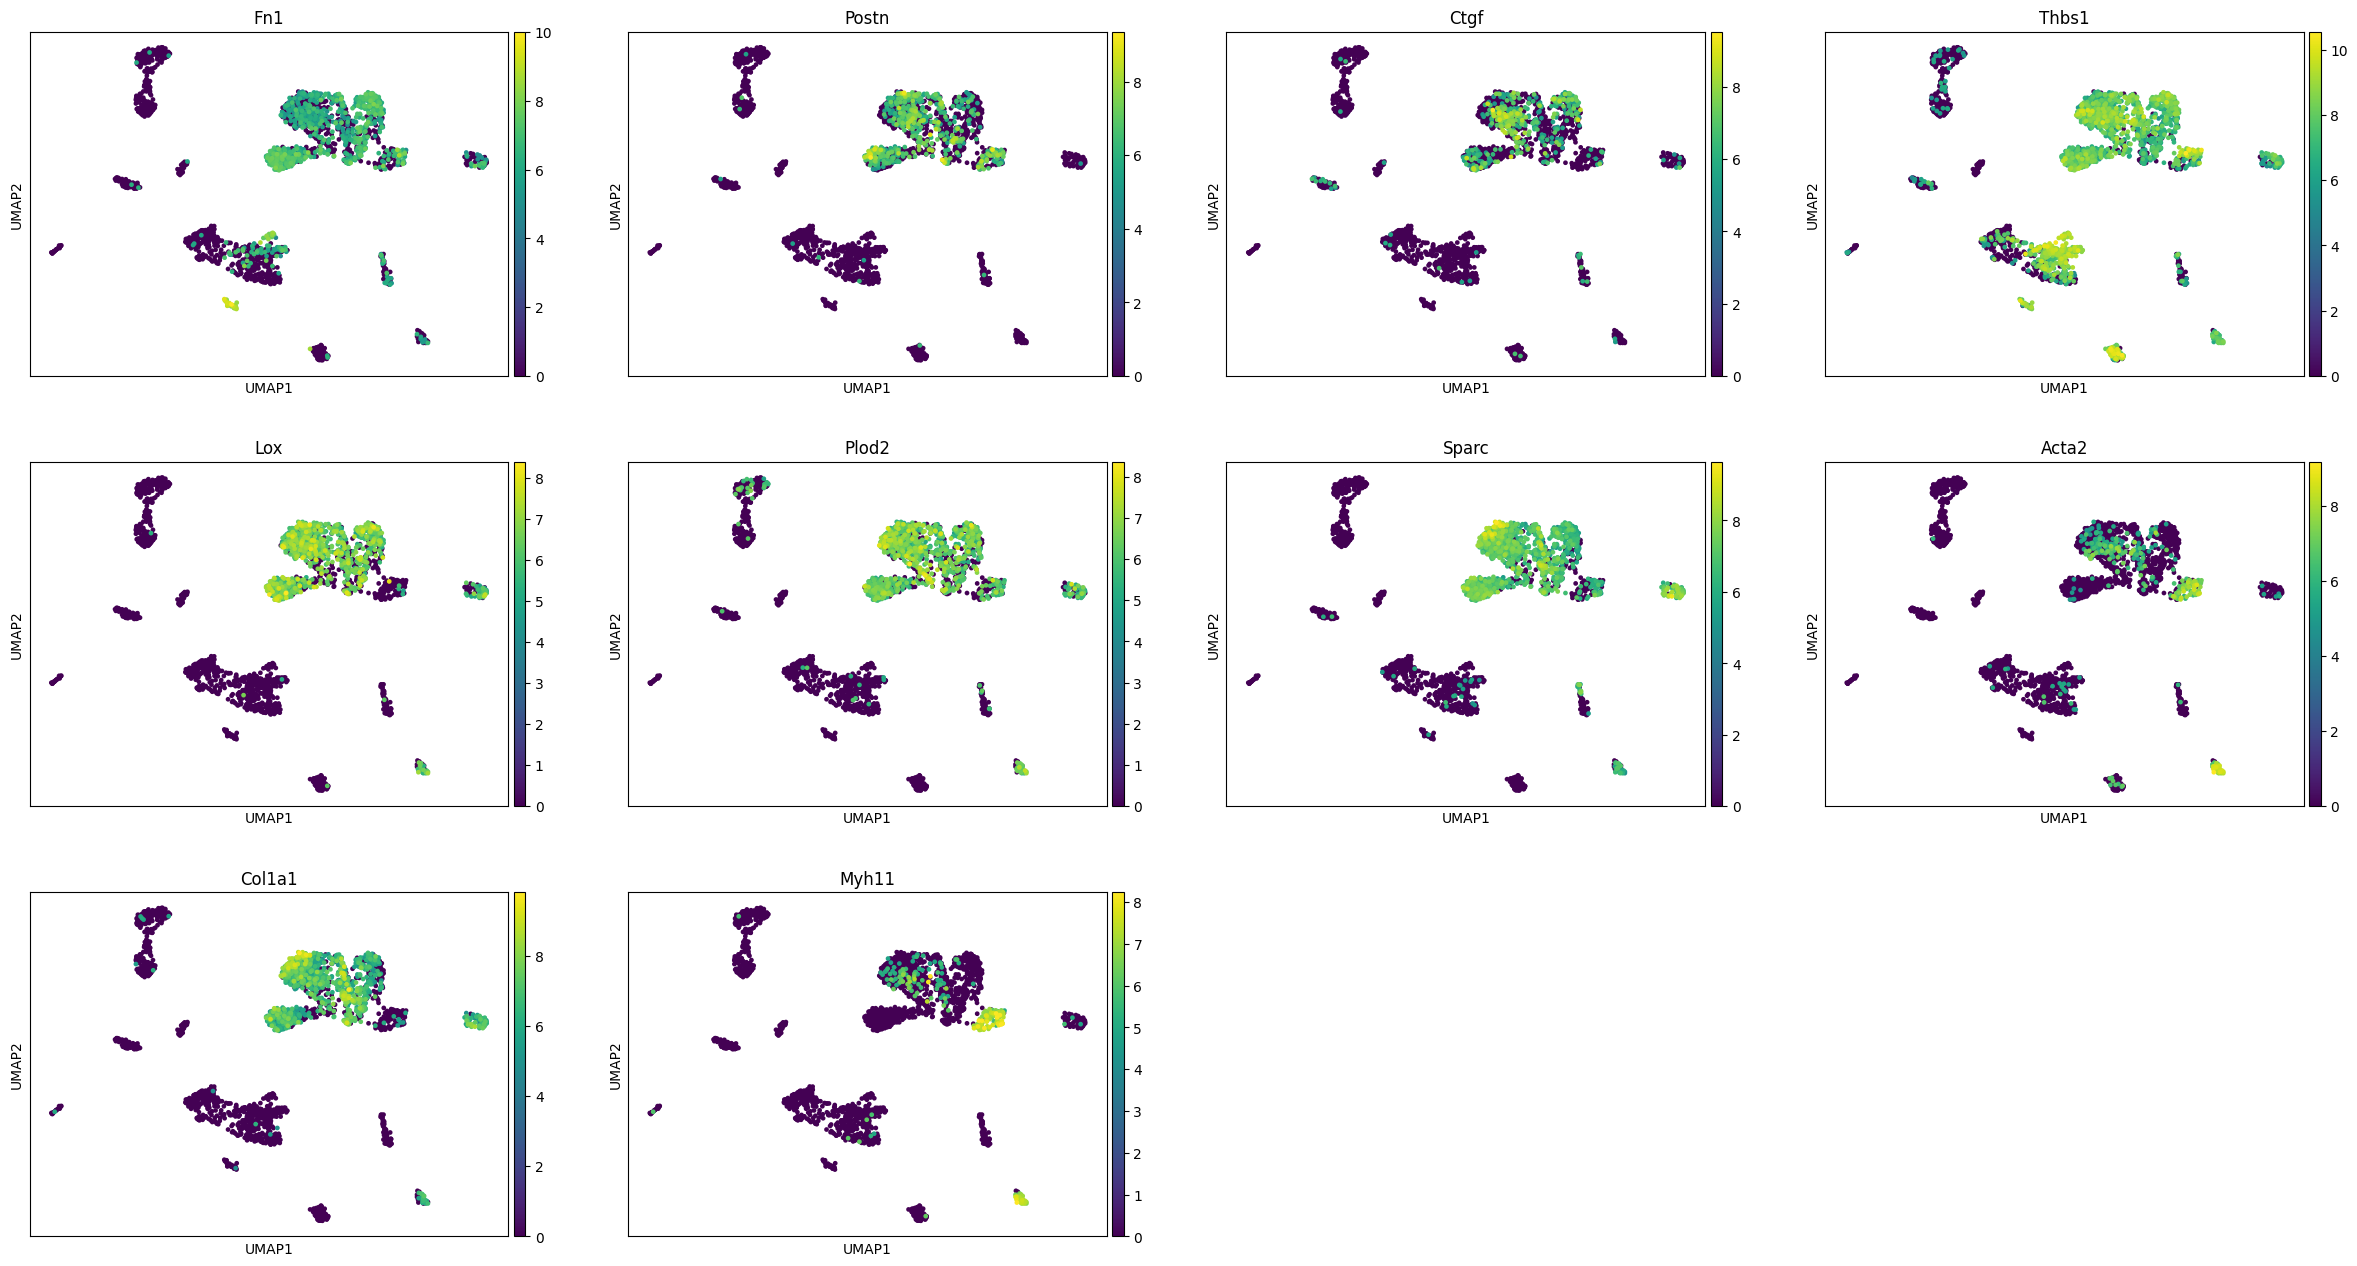

In [9]:
sc.pl.umap(adata, color = ['Fn1', 'Postn', 'Ctgf', 'Thbs1', 'Lox', 'Plod2', 'Sparc', 'Acta2', 'Col1a1', 'Myh11'])

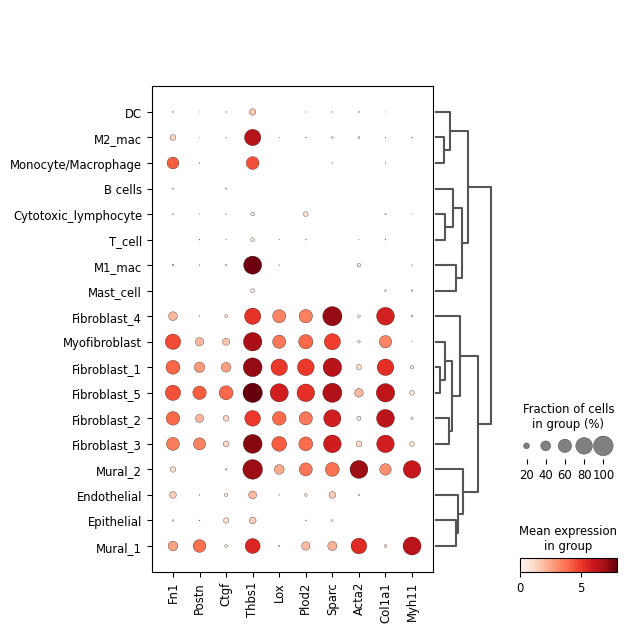

In [10]:
sc.pl.dotplot(adata, var_names = ['Fn1', 'Postn', 'Ctgf', 'Thbs1', 'Lox', 'Plod2', 'Sparc', 'Acta2', 'Col1a1', 'Myh11'], groupby = 'cell_type', dendrogram = True)

The reference dataset has `71439` cells and `26727` genes. In this case, I chose `celltype_level3` as the reference annotation ("ground truth") because it had the best resolution on cell types, but again, this could be any annotation or even a leiden clustering.

### Run Benchmark

Thanks to the functions that we defined above, we can run the benchmarking with just one line. Here we benchmark against the `celltype_level3` annotation.

In [11]:
#plt.rcParams['figure.figsize'] = (2,2)

... Subsetting adata
... Creating new UMAP
Benchmarking cell_type
... Calculating AMI and ARI for full panel
... Calculating AMI and ARI for subsetted panel
... Making  plots


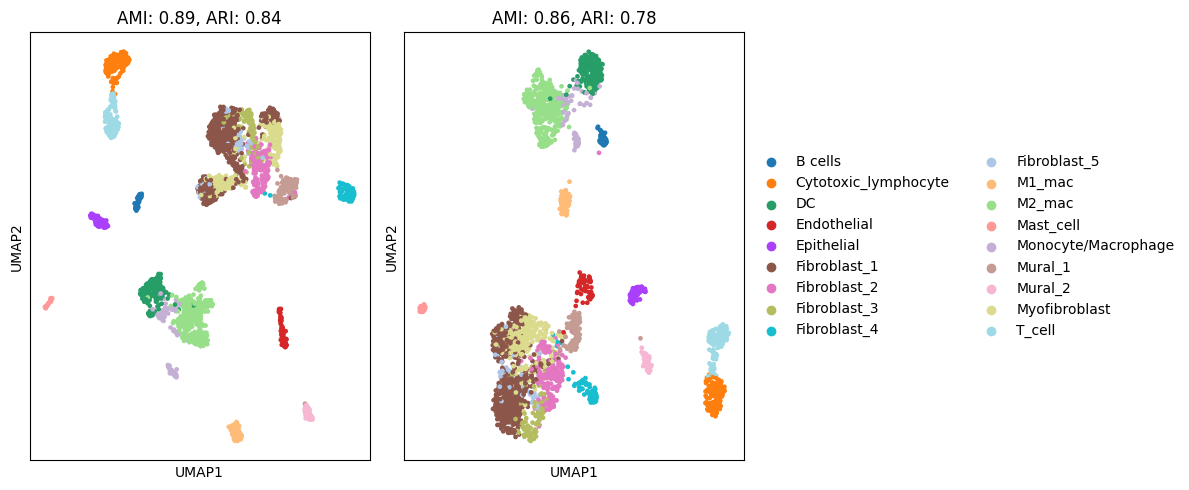

In [12]:
benchmark(adata, panel, ['cell_type'])

... Subsetting adata
... Creating new UMAP
Benchmarking cell_class
... Calculating AMI and ARI for full panel
... Calculating AMI and ARI for subsetted panel
... Making  plots


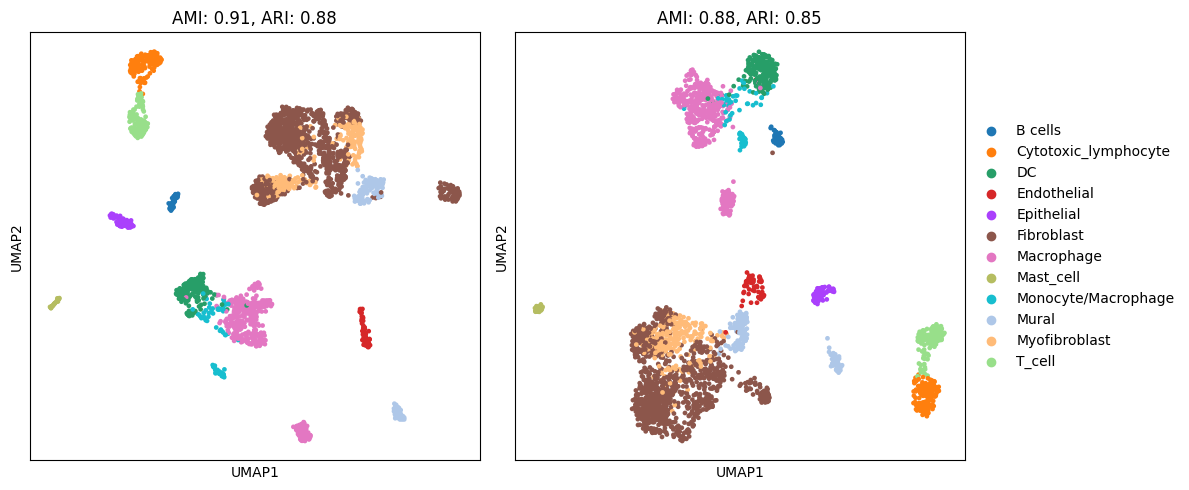

In [13]:
benchmark(adata, panel, ['cell_class'])

... Subsetting adata
... Creating new UMAP
Benchmarking leiden
... Calculating AMI and ARI for full panel
... Calculating AMI and ARI for subsetted panel
... Making  plots


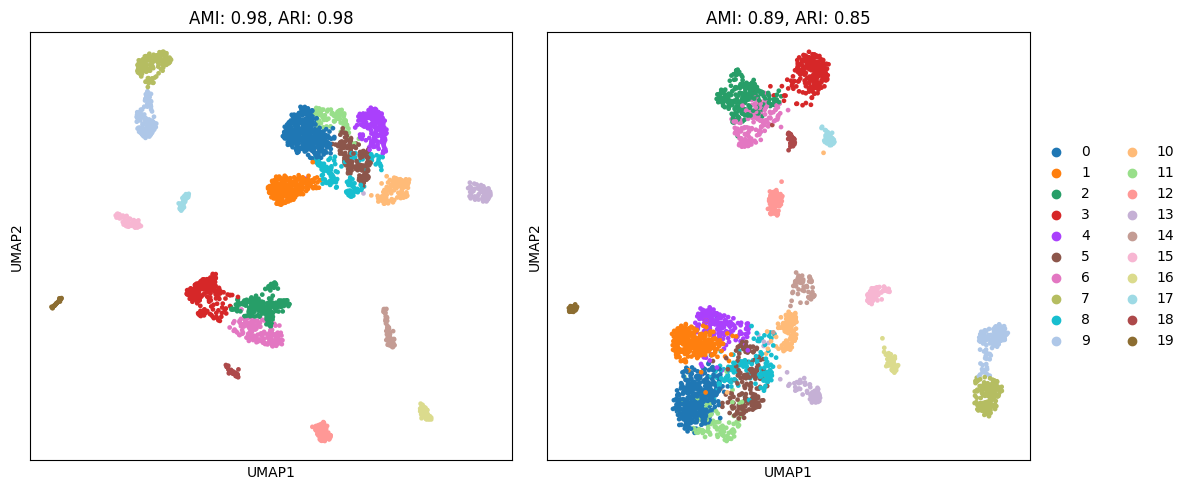

In [14]:
benchmark(adata, panel, ['leiden'])

The function plots two UMAPs, colored by the reference annotation. The left plot shows the original UMAP (based on the HVGs) and it has an excellent AMI and ARI score (both are close to 1), indicating, that the overall celltype resolution is working well. 

The plot on the right side shows the UMAP based on the subsetted gene panel. You can already see, that some separation between the cell types is not as good, but the overall AMI and ARI score are still pretty good. Unfortunately, there are not absolute cutoff values for both the AMI and ARI, but this is a good strategy to compare different panels to each other.

However, the AMI and ARI are dependent on the number of different clusters/ cell types in your reference annotation. The more cell types/clusters, the worse the AMI and ARI scores usually become.

We can see this, if we do the same benchmarking against the level1 annotation (which should be more coarse). 

In [15]:
print("Number of genes in panel:", panel['Gene'].nunique())
print("Number of highly variable genes:", adata.var['highly_variable'].sum())

Number of genes in panel: 490
Number of highly variable genes: 2000


# compare all 3

In [16]:
def benchmark_panel(adata_scanpy, adata_seurat, adata_panel, key):
    """
    Compares Scanpy HVG, Seurat HVG, and Panel-based dimensionality reductions.
    
    Parameters
    ----------
    adata_scanpy : AnnData
        Data with HVGs selected using Scanpy defaults.
    adata_seurat : AnnData
        Data with HVGs selected using Seurat flavor, top 2k genes.
    adata_panel : AnnData
        Data subset to panel genes.
    key : str
        Key in .obs to benchmark.
    """
    adata_scanpy = adata_scanpy.copy()
    adata_seurat = adata_seurat.copy()
    adata_panel = adata_panel.copy()

    print("... Calculating AMI and ARI for Scanpy HVGs")
    ari_scanpy, ami_scanpy = calc_metrics(adata_scanpy, key)

    print("... Calculating AMI and ARI for Seurat HVGs")
    ari_seurat, ami_seurat = calc_metrics(adata_seurat, key)

    print("... Calculating AMI and ARI for Panel genes")
    ari_panel, ami_panel = calc_metrics(adata_panel, key)

    print("... Making plots")
    fig, axes = plt.subplots(1, 3, figsize=(12, 5))

    sc.pl.umap(adata_scanpy, color=key, ax=axes[0], show=False, legend_loc=None)
    sc.pl.umap(adata_seurat, color=key, ax=axes[1], show=False, legend_loc=None)
    sc.pl.umap(adata_panel, color=key, ax=axes[2], show=False, legend_loc=None)

    axes[0].set_title(f"Scanpy HVGs (default)\nAMI: {ami_scanpy:.2f}, ARI: {ari_scanpy:.2f}")
    axes[1].set_title(f"Top 2k HVGs (seurat-v3)\nAMI: {ami_seurat:.2f}, ARI: {ari_seurat:.2f}")
    axes[2].set_title(f"Draft Panel Genes\nAMI: {ami_panel:.2f}, ARI: {ari_panel:.2f}")

    fig.tight_layout()
    return fig, axes

In [17]:
def benchmark(adata, panel, keys):
    """
    Benchmark Scanpy HVGs, Seurat HVGs, and Panel gene selections.
    
    Parameters
    ----------
    adata : AnnData
    panel : pd.DataFrame
    keys : list of obs keys to benchmark
    """
    print("... Creating Scanpy HVG subset")
    adata_scanpy = adata.copy()
    sc.pp.highly_variable_genes(adata_scanpy, min_mean=0.0125, max_mean=3, min_disp=0.5)
    adata_scanpy = adata_scanpy[:, adata_scanpy.var['highly_variable']].copy()
    print(f"Number of genes (Scanpy HVGs): {adata_scanpy.shape[1]}")  # print count
    sc.tl.pca(adata_scanpy, use_highly_variable=True)
    sc.pp.neighbors(adata_scanpy)
    sc.tl.umap(adata_scanpy)

    print("... Creating Seurat HVG subset (2k)")
    adata_seurat = adata.copy()
    adata_seurat.X = adata_seurat.layers["counts"].copy()
    sc.pp.highly_variable_genes(adata_seurat, n_top_genes=2000, flavor="seurat_v3")
    adata_seurat = adata_seurat[:, adata_seurat.var['highly_variable']].copy()
    print(f"Number of genes (Seurat top 2k): {adata_seurat.shape[1]}")  # print count
    sc.tl.pca(adata_seurat, use_highly_variable=True)
    sc.pp.neighbors(adata_seurat)
    sc.tl.umap(adata_seurat)

    print("... Subsetting to panel genes")
    adata_panel = adata[:, adata.var['features'].isin(panel['Gene'])].copy()
    print(f"Number of genes (Panel): {adata_panel.shape[1]}") 
    sc.tl.pca(adata_panel, svd_solver='arpack', use_highly_variable=False)
    sc.pp.neighbors(adata_panel)
    sc.tl.umap(adata_panel)

    for k in keys:
        print(f"Benchmarking {k}")
        benchmark_panel(adata_scanpy, adata_seurat, adata_panel, k)

... Creating Scanpy HVG subset
Number of genes (Scanpy HVGs): 2836
... Creating Seurat HVG subset (2k)
Number of genes (Seurat top 2k): 2000
... Subsetting to panel genes
Number of genes (Panel): 488
Benchmarking cell_type
... Calculating AMI and ARI for Scanpy HVGs
... Calculating AMI and ARI for Seurat HVGs
... Calculating AMI and ARI for Panel genes
... Making plots


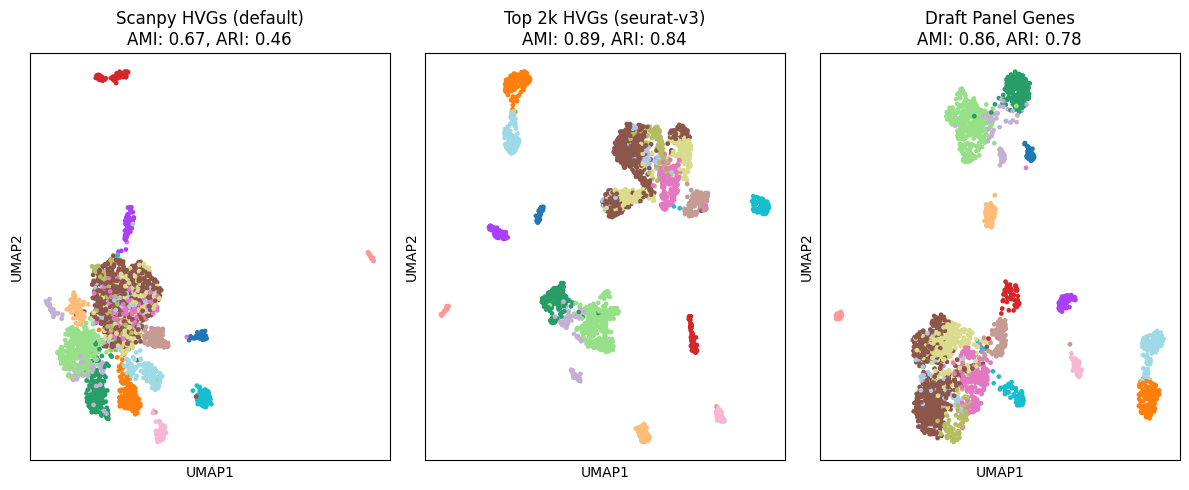

In [18]:
benchmark(adata, panel, ['cell_type'])

In [19]:
import matplotlib.patches as mpatches

def plot_legend(adata, key):
    """
    Plots a standalone legend for a categorical variable in adata.obs[key],
    preserving color order from adata.uns by sorting labels alphabetically.
    
    Parameters
    ----------
    adata : AnnData
    key : str
        obs column containing categorical labels (e.g. 'cell_type')
    """
    unique_labels = sorted(adata.obs[key].unique())  # sorted to match color order

    if f"{key}_colors" in adata.uns:
        color_list = adata.uns[f"{key}_colors"]
    else:
        color_list = sc.pl.palettes.default_102[:len(unique_labels)]

    color_map = dict(zip(unique_labels, color_list))
    patches = [mpatches.Patch(color=color_map[label], label=label) for label in unique_labels]

    fig, ax = plt.subplots(figsize=(6, len(unique_labels) * 0.35))
    ax.legend(handles=patches, loc='center left', frameon=False)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

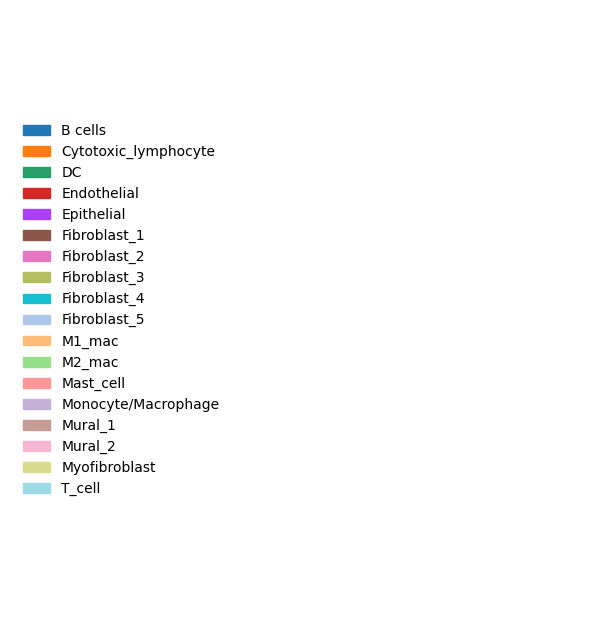

In [20]:
plot_legend(adata, 'cell_type')